<a href="https://colab.research.google.com/github/ishansurdi/Customer-Churn/blob/main/CustomerChrun_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Chrun Prediction - NoteBook

## Part 1: Preprocessing and Cleaning

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# module import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
# Reading CSV file

df = pd.read_csv("/content/drive/MyDrive/MITWPU_ML_Project/CustomerChrunDataSet.csv")

In [7]:
# Knowing about DataFrame / Data

# print("======================================")
# print(df.head())
print("Info")
print(df.info())
print("======================================")

print("Describe: ")
print(df.describe())
print("======================================")


print("Null Details")
print(df.isnull().sum())
print("======================================")

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   obj

> To detect outlier we will use box plot but for box plot we require number (not binary) for better understadning, that's why discarding 'SeniorCitizen' Column from box plot

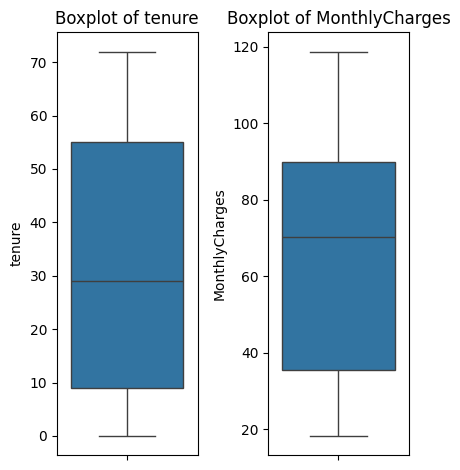

tenure outliers count: 0
MonthlyCharges outliers count: 0


In [11]:
# Outlier Detection through BoxPlot

# columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges']
columns = ['tenure', 'MonthlyCharges']

# Plot boxplots

for i, col in enumerate(columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Detect outliers using IQR method
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} outliers count: {outliers.shape[0]}")


In [10]:
temp = df['SeniorCitizen']
print(temp)

0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64


In [15]:
# Check for duplicates in each column
for col in df.columns:
    duplicated_values = df[col][df[col].duplicated(keep=False)].unique()
    if len(duplicated_values) > 0:
        print(f"Column '{col}' has duplicates. Sample duplicate values: {duplicated_values[:10]}")
    else:
        print(f"Column '{col}' has no duplicates.")


Column 'customerID' has no duplicates.
Column 'gender' has duplicates. Sample duplicate values: ['Female' 'Male']
Column 'SeniorCitizen' has duplicates. Sample duplicate values: [0 1]
Column 'Partner' has duplicates. Sample duplicate values: ['Yes' 'No']
Column 'Dependents' has duplicates. Sample duplicate values: ['No' 'Yes']
Column 'tenure' has duplicates. Sample duplicate values: [ 1 34  2 45  8 22 10 28 62 13]
Column 'PhoneService' has duplicates. Sample duplicate values: ['No' 'Yes']
Column 'MultipleLines' has duplicates. Sample duplicate values: ['No phone service' 'No' 'Yes']
Column 'InternetService' has duplicates. Sample duplicate values: ['DSL' 'Fiber optic' 'No']
Column 'OnlineSecurity' has duplicates. Sample duplicate values: ['No' 'Yes' 'No internet service']
Column 'OnlineBackup' has duplicates. Sample duplicate values: ['Yes' 'No' 'No internet service']
Column 'DeviceProtection' has duplicates. Sample duplicate values: ['No' 'Yes' 'No internet service']
Column 'TechSuppo

In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Encoding

In [18]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [19]:
df = pd.get_dummies(df, columns=['PaymentMethod', 'Contract', 'InternetService'], drop_first=True)

In [21]:
scaler = StandardScaler()
df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

In [24]:
# Correct way to fill NaNs
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [25]:
print("Null Details: ")
print(df.isnull().sum())

Null Details: 
customerID                               0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
Contract_One year                        0
Contract_Two year                      

Correlation of numeric features with Churn:

SeniorCitizen      NaN
Partner            NaN
Dependents         NaN
tenure             NaN
PhoneService       NaN
PaperlessBilling   NaN
MonthlyCharges     NaN
TotalCharges       NaN
Churn              NaN
Name: Churn, dtype: float64


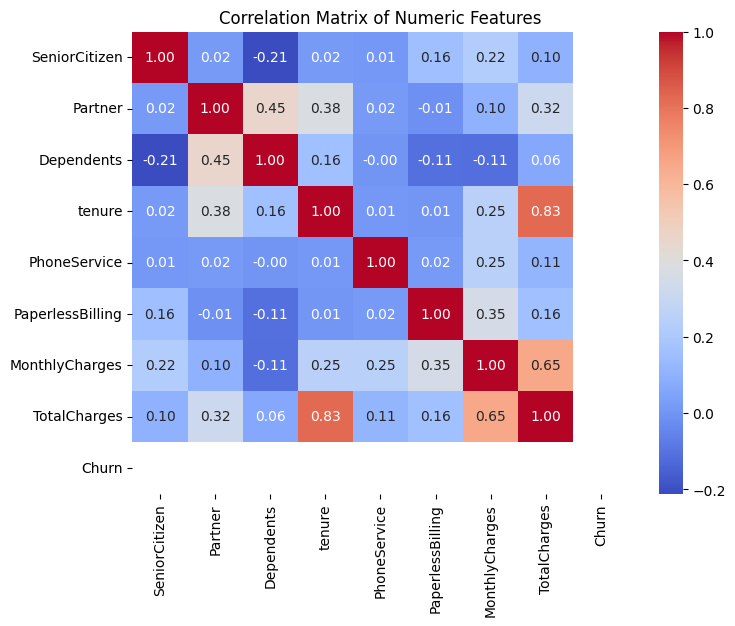

In [26]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation with target
correlation_with_target = df[numeric_cols].corr()['Churn'].sort_values(ascending=False)
print("Correlation of numeric features with Churn:\n")
print(correlation_with_target)

# Optional: visualize using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()